# Avaliação de Embedding Models com `gensim` e os dados abertos do Cornell Eval

Este notebook foi adaptado para usar os recursos públicos liberados junto ao paper **"Evaluation methods for unsupervised word embeddings"**:

- `query_inventory.zip`
- `judgements.zip`
- `embeddings.zip` (opcional, ~780 MB)
- `wiki_2008.zip` (opcional, ~1.3 GB)

Objetivo prático do notebook:

1. baixar e normalizar o **query inventory** e os **human judgements** liberados pelos autores
2. treinar modelos `gensim` locais (**CBOW**, **Skip-gram + negative sampling**, **Skip-gram + hierarchical softmax**) ou, opcionalmente, carregar os **embeddings liberados**
3. reproduzir uma versão prática das avaliações discutidas no artigo:
   - relatedness / similarity
   - analogias
   - direct comparison por query
   - coherence / intrusion
   - probe de frequência
   - sentiment classification
   - noun phrase chunking

Observação: as tarefas **direct comparison** e **coherence** passam a usar o **query inventory do Cornell** como base. O arquivo de **judgements** também é carregado e resumido para inspeção e comparação.


In [1]:

# Instalação de dependências
!pip -q install -U gensim datasets nltk scikit-learn sklearn-crfsuite seqeval tqdm requests


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 122.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [2]:

# Downloads do NLTK
import nltk

for pkg in ["punkt", "punkt_tab", "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng", "universal_tagset", "conll2000"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass


In [3]:

import os
import re
import io
import math
import json
import gzip
import time
import shutil
import random
import zipfile
import itertools
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import gensim
import gensim.downloader as api
from gensim.models import Word2Vec, KeyedVectors
from gensim.test.utils import datapath

from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer

import sklearn_crfsuite
from seqeval.metrics import f1_score as seq_f1_score
import requests

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("gensim:", gensim.__version__)


gensim: 4.4.0


## 1. Configuração


In [4]:

FAST_MODE = True

# Diretórios
ROOT_DIR = Path("cornell_embedding_eval")
RAW_DIR = ROOT_DIR / "raw"
EXTRACT_DIR = ROOT_DIR / "extracted"
OUTPUT_DIR = ROOT_DIR / "outputs"

for d in [ROOT_DIR, RAW_DIR, EXTRACT_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# URLs abertas do Cornell Eval
URLS = {
    "query_inventory": "https://www.cs.cornell.edu/~schnabts/eval/query_inventory.zip",
    "judgements": "https://www.cs.cornell.edu/~schnabts/eval/judgements.zip",
    "embeddings": "https://www.cs.cornell.edu/~schnabts/eval/embeddings.zip",
    "wiki_2008": "https://www.cs.cornell.edu/~schnabts/eval/wiki_2008.zip",
}

# Recursos que sempre serão usados
DOWNLOAD_QUERY_INVENTORY = True
DOWNLOAD_JUDGEMENTS = True

# Recursos opcionais (maiores)
DOWNLOAD_RELEASED_EMBEDDINGS = False
DOWNLOAD_RELEASED_WIKI = False

# Treino local com gensim
TRAIN_LOCAL_MODELS = True
USE_RELEASED_WIKI_FOR_TRAINING = False   # só funciona se DOWNLOAD_RELEASED_WIKI=True
TEXT8_TOKEN_LIMIT = 1_500_000 if FAST_MODE else None
RELEASED_WIKI_MAX_LINES = 150_000 if FAST_MODE else None
RELEASED_WIKI_MAX_TOKENS = 2_000_000 if FAST_MODE else None

# Hiperparâmetros de treino local
VECTOR_SIZE = 100
WINDOW = 5
MIN_COUNT = 5
EPOCHS = 5 if FAST_MODE else 10
NEGATIVE = 10
SAMPLE = 1e-5
WORKERS = max(1, os.cpu_count() or 2)

# Released embeddings (opcional)
# Coloque padrões de nome se quiser carregar embeddings do archive liberado.
# Exemplo: ["cbow", "glove", "tscca"]
SELECT_RELEASED_PATTERNS = []
RELEASED_VECTOR_LIMIT = 200_000 if FAST_MODE else None

# Query inventory / tarefas humanas
N_QUERY_WORDS_FALLBACK = 40 if FAST_MODE else 100
DIRECT_COMPARISON_RANKS = [1, 5, 10] if FAST_MODE else [1, 5, 10, 50]

# Sentiment
IMDB_SAMPLE_PER_SPLIT = 3000 if FAST_MODE else None
USE_IMDB_CV = False

# Chunking
CHUNK_TRAIN_LIMIT = 2000 if FAST_MODE else None
CHUNK_TEST_LIMIT = 500 if FAST_MODE else None
EMBEDDING_DIM_FOR_CHUNK = 32 if FAST_MODE else VECTOR_SIZE

# Frequency probe
FREQ_THRESHOLDS = [100, 500, 1000, 2500, 5000, 10000]

print("FAST_MODE =", FAST_MODE)
print("ROOT_DIR =", ROOT_DIR.resolve())


FAST_MODE = True
ROOT_DIR = /content/cornell_embedding_eval


## 2. Download e extração dos dados abertos do Cornell Eval


In [5]:

def download_file(url, dst_path, chunk_size=1024 * 1024, force=False):
    dst_path = Path(dst_path)
    if dst_path.exists() and not force:
        print(f"[skip] {dst_path.name} já existe")
        return dst_path

    print(f"[download] {url}")
    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(dst_path, "wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc=dst_path.name) as pbar:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
    return dst_path

def extract_zip(zip_path, out_dir, force=False):
    zip_path = Path(zip_path)
    out_dir = Path(out_dir)
    marker = out_dir / ".done"
    if out_dir.exists() and marker.exists() and not force:
        print(f"[skip] extração já pronta: {out_dir.name}")
        return out_dir

    out_dir.mkdir(parents=True, exist_ok=True)
    print(f"[extract] {zip_path.name} -> {out_dir}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_dir)
    marker.write_text("ok")
    return out_dir

def maybe_prepare_resource(name, should_download):
    if not should_download:
        return None
    zip_path = RAW_DIR / f"{name}.zip"
    out_dir = EXTRACT_DIR / name
    download_file(URLS[name], zip_path)
    extract_zip(zip_path, out_dir)
    return out_dir

query_inventory_dir = maybe_prepare_resource("query_inventory", DOWNLOAD_QUERY_INVENTORY)
judgements_dir = maybe_prepare_resource("judgements", DOWNLOAD_JUDGEMENTS)
released_embeddings_dir = maybe_prepare_resource("embeddings", DOWNLOAD_RELEASED_EMBEDDINGS)
released_wiki_dir = maybe_prepare_resource("wiki_2008", DOWNLOAD_RELEASED_WIKI)


[download] https://www.cs.cornell.edu/~schnabts/eval/query_inventory.zip


query_inventory.zip:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

[extract] query_inventory.zip -> cornell_embedding_eval/extracted/query_inventory
[download] https://www.cs.cornell.edu/~schnabts/eval/judgements.zip


judgements.zip:   0%|          | 0.00/83.7k [00:00<?, ?B/s]

[extract] judgements.zip -> cornell_embedding_eval/extracted/judgements


In [6]:

def list_files(base_dir):
    if base_dir is None or not Path(base_dir).exists():
        return pd.DataFrame(columns=["path", "suffix", "size_mb"])
    rows = []
    for p in sorted(Path(base_dir).rglob("*")):
        if p.is_file():
            rows.append({
                "path": str(p.relative_to(base_dir)),
                "suffix": p.suffix.lower(),
                "size_mb": round(p.stat().st_size / (1024**2), 3),
            })
    return pd.DataFrame(rows)

for name, base in [
    ("query_inventory", query_inventory_dir),
    ("judgements", judgements_dir),
    ("embeddings", released_embeddings_dir),
    ("wiki_2008", released_wiki_dir),
]:
    print(f"\n### {name}")
    display(list_files(base).head(50))



### query_inventory


,path,suffix,size_mb
0,.done,,0.000
1,query_inventory.tsv,.tsv,0.003



### judgements


,path,suffix,size_mb
0,.done,,0.000
1,evaluation/direct-comparison/100_NN.csv,.csv,0.009
2,evaluation/direct-comparison/10_NN.csv,.csv,0.009
3,evaluation/direct-comparison/15_NN.csv,.csv,0.009
4,evaluation/direct-comparison/1_NN.csv,.csv,0.009
5,evaluation/direct-comparison/25_NN.csv,.csv,0.009
6,evaluation/direct-comparison/3_NN.csv,.csv,0.009
7,evaluation/direct-comparison/50_NN.csv,.csv,0.009
8,evaluation/direct-comparison/5_NN.csv,.csv,0.009
9,evaluation/direct-comparison/mturk.csv,.csv,0.064



### embeddings


,path,suffix,size_mb



### wiki_2008


,path,suffix,size_mb


## 3. Carregar e normalizar `query_inventory.tsv` e `judgements.tsv`


In [7]:

def normalize_columns(df):
    out = df.copy()
    out.columns = [
        re.sub(r"_+", "_", re.sub(r"[^a-z0-9]+", "_", str(c).strip().lower())).strip("_")
        for c in out.columns
    ]
    return out

def load_all_tsvs(base_dir):
    tables = {}
    if base_dir is None:
        return tables
    for path in sorted(Path(base_dir).rglob("*.tsv")):
        try:
            df = pd.read_csv(path, sep="\t")
            df = normalize_columns(df)
            tables[path] = df
        except Exception as e:
            print(f"Falha ao ler {path}: {e}")
    return tables

inventory_tables = load_all_tsvs(query_inventory_dir)
judgement_tables = load_all_tsvs(judgements_dir)

print("TSVs do query_inventory:", len(inventory_tables))
print("TSVs do judgements:", len(judgement_tables))

def table_overview(tables):
    rows = []
    for path, df in tables.items():
        rows.append({
            "file": str(path.name),
            "rows": len(df),
            "cols": len(df.columns),
            "columns": ", ".join(df.columns[:20]),
        })
    return pd.DataFrame(rows)

display(table_overview(inventory_tables))
display(table_overview(judgement_tables))


TSVs do query_inventory: 1
TSVs do judgements: 0


,file,rows,cols,columns
0,query_inventory.tsv,100,4,"word, wordnet_category, frequency, abstract_co..."


""


In [8]:

def find_column(columns, aliases):
    cols = list(columns)
    lowered = {c.lower(): c for c in cols}

    for a in aliases:
        if a in lowered:
            return lowered[a]

    # match parcial
    for c in cols:
        cl = c.lower()
        for a in aliases:
            if a in cl:
                return c
    return None

def guess_inventory_table(tables):
    best_path, best_score = None, -1
    for path, df in tables.items():
        cols = list(df.columns)
        score = 0
        name = path.name.lower()
        if "query" in name:
            score += 3
        if "inventory" in name:
            score += 3
        if find_column(cols, ["query", "word", "term", "target", "query_word", "anchor", "item"]):
            score += 4
        if find_column(cols, ["pos", "part_of_speech", "tag"]):
            score += 1
        if find_column(cols, ["frequency", "freq", "count", "rank"]):
            score += 1
        if score > best_score:
            best_path, best_score = path, score
    return best_path

inventory_path = guess_inventory_table(inventory_tables)
print("Tabela de inventory escolhida:", inventory_path)

def canonicalize_query_inventory(df):
    df = normalize_columns(df)
    cols = list(df.columns)

    query_col = find_column(cols, ["query", "word", "term", "target", "query_word", "anchor", "item"])
    pos_col = find_column(cols, ["pos", "part_of_speech", "tag"])
    freq_col = find_column(cols, ["frequency", "freq", "count", "corpus_frequency"])
    rank_col = find_column(cols, ["rank", "frequency_rank", "corpus_rank"])
    abs_col = find_column(cols, ["abstractness", "abstract", "concrete", "concreteness"])

    # fallback para a primeira coluna textual com boa cardinalidade
    if query_col is None:
        object_cols = [c for c in cols if str(df[c].dtype) == "object"]
        if object_cols:
            object_cols = sorted(object_cols, key=lambda c: df[c].nunique(), reverse=True)
            query_col = object_cols[0]

    out = pd.DataFrame()
    out["query"] = df[query_col].astype(str).str.strip().str.lower() if query_col else pd.Series(dtype=str)

    if pos_col:
        out["pos"] = df[pos_col].astype(str)
    else:
        out["pos"] = np.nan

    if freq_col:
        out["frequency"] = pd.to_numeric(df[freq_col], errors="coerce")
    else:
        out["frequency"] = np.nan

    if rank_col:
        out["rank"] = pd.to_numeric(df[rank_col], errors="coerce")
    else:
        out["rank"] = np.nan

    if abs_col:
        out["abstractness"] = df[abs_col]
    else:
        out["abstractness"] = np.nan

    out = out.dropna(subset=["query"]).drop_duplicates("query").reset_index(drop=True)

    # Se existe frequency e não existe rank, inferir rank
    if out["rank"].isna().all() and out["frequency"].notna().any():
        temp = out[["query", "frequency"]].dropna().sort_values("frequency", ascending=False).reset_index(drop=True)
        rank_map = {q: i + 1 for i, q in enumerate(temp["query"])}
        out["rank"] = out["query"].map(rank_map)

    return out

if inventory_path is not None:
    query_inventory_df = canonicalize_query_inventory(inventory_tables[inventory_path])
else:
    query_inventory_df = pd.DataFrame(columns=["query", "pos", "frequency", "rank", "abstractness"])

query_inventory_df.to_csv(OUTPUT_DIR / "cornell_query_inventory_normalized.csv", index=False)
print("Query inventory normalizado:", query_inventory_df.shape)
display(query_inventory_df.head(20))


Tabela de inventory escolhida: cornell_embedding_eval/extracted/query_inventory/query_inventory.tsv
Query inventory normalizado: (100, 5)


,query,pos,frequency,rank,abstractness
0,revolutionary,NaN,25388,25,NaN
1,casual,NaN,4979,53,NaN
2,theoretical,NaN,12001,41,NaN
3,novel,NaN,92640,6,NaN
4,respected,NaN,12173,40,NaN
5,bright,NaN,17247,31,NaN
6,feasible,NaN,2682,70,NaN
7,responsive,NaN,1474,73,NaN
8,bipolar,NaN,1837,72,NaN
9,forceful,NaN,1258,74,NaN


In [9]:

def summarize_judgement_tables(judgement_tables):
    rows = []
    for path, df in judgement_tables.items():
        cols = list(df.columns)
        col_string = " ".join(cols)

        task = "unknown"
        if "intrud" in col_string:
            task = "coherence_intrusion"
        elif "neighbor" in col_string or "rank" in col_string or "choice" in col_string:
            task = "direct_comparison_or_relatedness"

        rows.append({
            "file": path.name,
            "rows": len(df),
            "n_columns": len(cols),
            "task_guess": task,
            "columns": ", ".join(cols[:30]),
        })
    return pd.DataFrame(rows)

judgement_overview_df = summarize_judgement_tables(judgement_tables)
judgement_overview_df.to_csv(OUTPUT_DIR / "cornell_judgements_overview.csv", index=False)
display(judgement_overview_df)


""


## 4. Corpus de treino: usar `wiki_2008` liberado pelos autores ou fallback para `text8`


In [10]:

def find_largest_text_like_file(base_dir):
    if base_dir is None or not Path(base_dir).exists():
        return None
    candidates = []
    for p in Path(base_dir).rglob("*"):
        if p.is_file():
            if p.suffix.lower() in {"", ".txt", ".tok", ".tokens", ".text"}:
                if "readme" not in p.name.lower():
                    candidates.append(p)
    if not candidates:
        return None
    return max(candidates, key=lambda p: p.stat().st_size)

def iter_tokenized_lines(path, max_lines=None, max_tokens=None):
    total_tokens = 0
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line_idx, line in enumerate(f):
            if max_lines is not None and line_idx >= max_lines:
                break
            toks = line.strip().split()
            if not toks:
                continue
            if max_tokens is None:
                yield toks
            else:
                remaining = max_tokens - total_tokens
                if remaining <= 0:
                    break
                if len(toks) <= remaining:
                    yield toks
                    total_tokens += len(toks)
                else:
                    yield toks[:remaining]
                    total_tokens += remaining
                    break

def load_text8_sentences(limit_tokens=None):
    dataset = api.load("text8")
    sentences = []
    total_tokens = 0
    for sent in dataset:
        sent = list(sent)
        if limit_tokens is None:
            sentences.append(sent)
            continue
        if total_tokens >= limit_tokens:
            break
        remaining = limit_tokens - total_tokens
        if len(sent) <= remaining:
            sentences.append(sent)
            total_tokens += len(sent)
        else:
            sentences.append(sent[:remaining])
            total_tokens += remaining
            break
    return sentences

def load_training_sentences():
    if USE_RELEASED_WIKI_FOR_TRAINING and released_wiki_dir is not None:
        wiki_file = find_largest_text_like_file(released_wiki_dir)
        if wiki_file is None:
            raise FileNotFoundError("Não encontrei arquivo textual dentro de wiki_2008.zip")
        print("Usando released wiki:", wiki_file)
        sents = list(iter_tokenized_lines(
            wiki_file,
            max_lines=RELEASED_WIKI_MAX_LINES,
            max_tokens=RELEASED_WIKI_MAX_TOKENS,
        ))
        return sents

    print("Usando fallback text8 do gensim")
    return load_text8_sentences(TEXT8_TOKEN_LIMIT)

sentences = load_training_sentences()
reference_counter = Counter(token for sent in sentences for token in sent)
reference_rank = {w: i + 1 for i, (w, _) in enumerate(reference_counter.most_common())}

print("Número de sentenças/chunks:", len(sentences))
print("Número total de tokens:", sum(len(s) for s in sentences))
print("Vocabulário do corpus de referência:", len(reference_counter))
print("Top 10 palavras:", reference_counter.most_common(10))


Usando fallback text8 do gensim
[==================================================] 100.0% 31.6/31.6MB downloaded
Número de sentenças/chunks: 150
Número total de tokens: 1500000
Vocabulário do corpus de referência: 65588
Top 10 palavras: [('the', 94268), ('of', 54929), ('one', 39885), ('and', 37191), ('in', 33259), ('to', 28031), ('a', 27724), ('zero', 22940), ('nine', 22136), ('two', 17613)]


## 5. Treinar modelos locais com `gensim`


In [11]:

def train_w2v(sentences, *, sg, hs=0, negative=10, name="model"):
    print(f"Treinando {name} ...")
    model = Word2Vec(
        sentences=sentences,
        vector_size=VECTOR_SIZE,
        window=WINDOW,
        min_count=MIN_COUNT,
        workers=WORKERS,
        sg=sg,
        hs=hs,
        negative=0 if hs == 1 else negative,
        sample=SAMPLE,
        epochs=EPOCHS,
        seed=SEED,
    )
    model.wv.fill_norms(force=True)
    return model

local_models = {}

if TRAIN_LOCAL_MODELS:
    cbow_model = train_w2v(sentences, sg=0, hs=0, negative=NEGATIVE, name="CBOW_local")
    skipgram_neg_model = train_w2v(sentences, sg=1, hs=0, negative=NEGATIVE, name="Skipgram_NEG_local")
    skipgram_hs_model = train_w2v(sentences, sg=1, hs=1, negative=0, name="Skipgram_HS_local")

    local_models = {
        "CBOW_local": cbow_model.wv,
        "Skipgram_NEG_local": skipgram_neg_model.wv,
        "Skipgram_HS_local": skipgram_hs_model.wv,
    }

print("Modelos locais:", list(local_models.keys()))


Treinando CBOW_local ...
Treinando Skipgram_NEG_local ...
Treinando Skipgram_HS_local ...
Modelos locais: ['CBOW_local', 'Skipgram_NEG_local', 'Skipgram_HS_local']


## 6. Opcional: carregar embeddings liberados pelos autores


In [12]:

def discover_embedding_candidates(base_dir):
    rows = []
    if base_dir is None:
        return pd.DataFrame(columns=["path", "name", "size_mb", "suffix"])
    for p in sorted(Path(base_dir).rglob("*")):
        if p.is_file():
            suffixes = "".join(p.suffixes).lower()
            if any(x in suffixes for x in [".txt", ".vec", ".word2vec", ".w2v", ".gz"]):
                if "readme" in p.name.lower():
                    continue
                rows.append({
                    "path": str(p),
                    "name": p.name,
                    "size_mb": round(p.stat().st_size / (1024**2), 3),
                    "suffix": suffixes,
                })
    return pd.DataFrame(rows).sort_values("size_mb", ascending=False)

embedding_candidates_df = discover_embedding_candidates(released_embeddings_dir)
display(embedding_candidates_df.head(50))


,path,name,size_mb,suffix


In [13]:

def open_text_auto(path):
    path = Path(path)
    if str(path).lower().endswith(".gz"):
        return gzip.open(path, "rt", encoding="utf-8", errors="ignore")
    return open(path, "r", encoding="utf-8", errors="ignore")

def _looks_like_int(x):
    try:
        int(x)
        return True
    except Exception:
        return False

def _looks_like_float(x):
    try:
        float(x)
        return True
    except Exception:
        return False

def load_text_vectors_generic(path, limit=None):
    words = []
    vecs = []
    vector_size = None
    kept = 0

    with open_text_auto(path) as f:
        first = f.readline().strip().split()

        # formato word2vec com header
        if len(first) == 2 and _looks_like_int(first[0]) and _looks_like_int(first[1]):
            vector_size = int(first[1])
        else:
            if len(first) > 2 and _looks_like_float(first[1]):
                words.append(first[0])
                vecs.append([float(x) for x in first[1:]])
                vector_size = len(vecs[-1])
                kept += 1

        for line in tqdm(f, desc=f"loading {Path(path).name}"):
            if limit is not None and kept >= limit:
                break
            parts = line.strip().split()
            if len(parts) <= 2:
                continue
            word = parts[0]
            try:
                vec = [float(x) for x in parts[1:]]
            except Exception:
                continue
            if vector_size is None:
                vector_size = len(vec)
            if len(vec) != vector_size:
                continue
            words.append(word)
            vecs.append(vec)
            kept += 1

    kv = KeyedVectors(vector_size=vector_size)
    kv.add_vectors(words, np.asarray(vecs, dtype=np.float32))
    kv.fill_norms(force=True)
    return kv

def load_released_embeddings(candidates_df, patterns, limit=None):
    loaded = {}
    if candidates_df.empty or not patterns:
        return loaded

    for pattern in patterns:
        sub = candidates_df[candidates_df["name"].str.lower().str.contains(pattern.lower(), na=False)]
        if sub.empty:
            print(f"Nenhum arquivo bateu com o padrão: {pattern}")
            continue

        path = sub.iloc[0]["path"]
        print(f"Carregando released embedding: {path}")
        try:
            kv = load_text_vectors_generic(path, limit=limit)
            loaded[f"released::{pattern}"] = kv
        except Exception as e:
            print(f"Falha em {path}: {e}")
    return loaded

released_models = load_released_embeddings(
    embedding_candidates_df,
    SELECT_RELEASED_PATTERNS,
    limit=RELEASED_VECTOR_LIMIT,
)

print("Released models carregados:", list(released_models.keys()))


Released models carregados: []


## 7. Consolidar conjunto de embeddings


In [14]:

models = {}
models.update(released_models)
models.update(local_models)

if not models:
    raise ValueError("Nenhum embedding foi carregado/treinado.")

def vocab_set(kv):
    return set(kv.key_to_index.keys())

shared_vocab = set.intersection(*(vocab_set(kv) for kv in models.values()))
print("Modelos disponíveis:", list(models.keys()))
print("Vocabulário compartilhado:", len(shared_vocab))


Modelos disponíveis: ['CBOW_local', 'Skipgram_NEG_local', 'Skipgram_HS_local']
Vocabulário compartilhado: 17929


## 8. Helpers gerais


In [15]:

TOKEN_RE = re.compile(r"[a-z]+")

def simple_tokenize(text):
    return TOKEN_RE.findall(str(text).lower())

def safe_vector(kv, word, dim=None):
    if dim is None:
        dim = kv.vector_size
    if word in kv:
        return kv[word]
    return np.zeros(dim, dtype=np.float32)

def get_neighbor_at_rank(kv, word, rank_k):
    if word not in kv:
        return None
    neighbors = kv.most_similar(word, topn=max(rank_k + 5, 30))
    seen = []
    for candidate, score in neighbors:
        if candidate != word:
            seen.append((candidate, score))
    if len(seen) >= rank_k:
        return seen[rank_k - 1]
    return None

def build_fallback_query_inventory(counter, candidate_vocab, n_queries=40):
    candidates = [w for w in candidate_vocab if counter.get(w, 0) >= 20]
    candidates = sorted(candidates, key=lambda w: counter[w], reverse=True)

    if len(candidates) < n_queries:
        return pd.DataFrame({"query": candidates})

    tagged = nltk.pos_tag(candidates[:10000], tagset="universal")
    by_pos = defaultdict(list)
    for word, pos in tagged:
        if pos in {"NOUN", "VERB", "ADJ", "ADV"}:
            by_pos[pos].append(word)

    freqs = np.array([counter[w] for w in candidates], dtype=np.int64)
    q1, q2 = np.quantile(freqs, [0.33, 0.66])

    def freq_bin(w):
        c = counter[w]
        if c <= q1:
            return "low"
        elif c <= q2:
            return "mid"
        return "high"

    selected = []
    target_pos = ["NOUN", "VERB", "ADJ", "ADV"]
    per_pos = max(1, n_queries // len(target_pos))

    for pos in target_pos:
        pool = by_pos.get(pos, [])
        bins = defaultdict(list)
        for w in pool:
            bins[freq_bin(w)].append(w)

        for b in ["high", "mid", "low"]:
            if bins[b]:
                take = max(1, per_pos // 3)
                selected.extend(bins[b][:take])

    selected = list(dict.fromkeys(selected))
    if len(selected) < n_queries:
        for w in candidates:
            if w not in selected:
                selected.append(w)
            if len(selected) >= n_queries:
                break

    out = pd.DataFrame({"query": selected[:n_queries]})
    out["pos"] = [pos for _, pos in nltk.pos_tag(out["query"].tolist(), tagset="universal")]
    out["frequency"] = [counter[w] for w in out["query"]]
    out["rank"] = [reference_rank[w] for w in out["query"]]
    out["abstractness"] = np.nan
    return out

if query_inventory_df.empty or "query" not in query_inventory_df.columns:
    query_inventory_df = build_fallback_query_inventory(reference_counter, shared_vocab, n_queries=N_QUERY_WORDS_FALLBACK)
else:
    # restringe às palavras presentes em pelo menos um embedding
    query_inventory_df = query_inventory_df[query_inventory_df["query"].isin(set.union(*(vocab_set(kv) for kv in models.values())))]
    if FAST_MODE:
        query_inventory_df = query_inventory_df.head(max(N_QUERY_WORDS_FALLBACK, min(100, len(query_inventory_df))))

query_inventory_df.to_csv(OUTPUT_DIR / "query_inventory_effective.csv", index=False)
print("Query inventory efetivo:", query_inventory_df.shape)
display(query_inventory_df.head(20))


Query inventory efetivo: (66, 5)


,query,pos,frequency,rank,abstractness
0,revolutionary,NaN,25388,25,NaN
1,casual,NaN,4979,53,NaN
2,theoretical,NaN,12001,41,NaN
3,novel,NaN,92640,6,NaN
4,respected,NaN,12173,40,NaN
5,bright,NaN,17247,31,NaN
6,feasible,NaN,2682,70,NaN
10,successfully,NaN,33045,21,NaN
11,consequently,NaN,14516,34,NaN
12,daily,NaN,54307,13,NaN


## 9. Avaliação intrínseca: relatedness / similarity


In [19]:
# ============================================================
# 9. AVALIAÇÃO INTRÍNSECA CLÁSSICA (DESATIVADA)
# ============================================================

USE_CLASSIC_SIMILARITY_DATASETS = False

if not USE_CLASSIC_SIMILARITY_DATASETS:
    print("Seção 9 ignorada.")
    print("Motivo: os benchmarks clássicos de similaridade "
          "(WordSim353, SimLex999, RareWords, MEN, MTurk771) "
          "não fazem parte dos 4 arquivos baixados da Cornell.")
    print("Com os arquivos da Cornell, foque nas avaliações:")
    print("- direct comparison")
    print("- coherence / intrusion")
    print("- análise de judgements")
    print("- comparação dos embeddings liberados")
else:
    # Aqui entraria a lógica dos benchmarks clássicos, caso você os baixasse separadamente
    pass

Seção 9 ignorada.
Motivo: os benchmarks clássicos de similaridade (WordSim353, SimLex999, RareWords, MEN, MTurk771) não fazem parte dos 4 arquivos baixados da Cornell.
Com os arquivos da Cornell, foque nas avaliações:
- direct comparison
- coherence / intrusion
- análise de judgements
- comparação dos embeddings liberados


## 10. Avaliação intrínseca: analogias


In [21]:

analogies_path = datapath("questions-words.txt")
print(analogies_path)


/usr/local/lib/python3.12/dist-packages/gensim/test/test_data/questions-words.txt


In [22]:

def evaluate_analogies(kv, restrict_vocab=50000):
    try:
        score, sections = kv.evaluate_word_analogies(
            analogies_path,
            restrict_vocab=restrict_vocab,
            case_insensitive=True,
        )
    except TypeError:
        score, sections = kv.evaluate_word_analogies(
            analogies_path,
            restrict_vocab=restrict_vocab,
        )

    section_rows = []
    for sec in sections:
        if sec.get("section") == "Total accuracy":
            continue
        correct = len(sec.get("correct", []))
        incorrect = len(sec.get("incorrect", []))
        total = correct + incorrect
        section_rows.append({
            "section": sec.get("section", "unknown"),
            "correct": correct,
            "incorrect": incorrect,
            "accuracy": correct / total if total else np.nan,
        })

    section_df = pd.DataFrame(section_rows)
    overall = {"overall_accuracy": score, "n_sections": len(section_df)}
    return overall, section_df

analogy_overall = []
analogy_sections = {}

for model_name, kv in models.items():
    overall, sec_df = evaluate_analogies(kv)
    overall["model"] = model_name
    analogy_overall.append(overall)
    analogy_sections[model_name] = sec_df

analogy_overall_df = pd.DataFrame(analogy_overall).sort_values("overall_accuracy", ascending=False)
analogy_overall_df.to_csv(OUTPUT_DIR / "analogy_overall.csv", index=False)
display(analogy_overall_df)


,overall_accuracy,n_sections,model
2,0.040546,14,Skipgram_HS_local
1,0.010415,14,Skipgram_NEG_local
0,0.000248,14,CBOW_local


## 11. Direct comparison task usando o `query_inventory` do Cornell

Aqui montamos as instâncias de comparação direta por query e por rank do vizinho.  
O notebook exporta um CSV pronto para anotação manual e também computa um **proxy automático** via maior cosseno do vizinho retornado.


In [23]:

effective_queries = query_inventory_df["query"].dropna().astype(str).str.lower().tolist()
effective_queries = [q for q in effective_queries if any(q in kv for kv in models.values())]

direct_rows = []
model_names = list(models.keys())

for query in effective_queries:
    meta = query_inventory_df[query_inventory_df["query"] == query].head(1)
    meta_dict = meta.iloc[0].to_dict() if len(meta) else {}

    for rank_k in DIRECT_COMPARISON_RANKS:
        for model_a, model_b in itertools.combinations(model_names, 2):
            a = get_neighbor_at_rank(models[model_a], query, rank_k)
            b = get_neighbor_at_rank(models[model_b], query, rank_k)
            if a is None or b is None:
                continue

            direct_rows.append({
                "query": query,
                "rank_k": rank_k,
                "model_a": model_a,
                "neighbor_a": a[0],
                "score_a": a[1],
                "model_b": model_b,
                "neighbor_b": b[0],
                "score_b": b[1],
                "proxy_winner": model_a if a[1] >= b[1] else model_b,
                "human_choice": "",
                "notes": "",
                "pos": meta_dict.get("pos", np.nan),
                "frequency": meta_dict.get("frequency", np.nan),
                "rank": meta_dict.get("rank", np.nan),
                "abstractness": meta_dict.get("abstractness", np.nan),
            })

direct_df = pd.DataFrame(direct_rows)
direct_df.to_csv(OUTPUT_DIR / "cornell_direct_comparison_tasks.csv", index=False)
print("Arquivo salvo em:", OUTPUT_DIR / "cornell_direct_comparison_tasks.csv")
display(direct_df.head(20))


Arquivo salvo em: cornell_embedding_eval/outputs/cornell_direct_comparison_tasks.csv


,query,rank_k,model_a,neighbor_a,score_a,model_b,neighbor_b,score_b,proxy_winner,human_choice,notes,pos,frequency,rank,abstractness
0,revolutionary,1,CBOW_local,millions,0.999696,Skipgram_NEG_local,bernard,0.996839,CBOW_local,,,NaN,25388,25,NaN
1,revolutionary,1,CBOW_local,millions,0.999696,Skipgram_HS_local,confederate,0.732971,CBOW_local,,,NaN,25388,25,NaN
2,revolutionary,1,Skipgram_NEG_local,bernard,0.996839,Skipgram_HS_local,confederate,0.732971,Skipgram_NEG_local,,,NaN,25388,25,NaN
3,revolutionary,5,CBOW_local,da,0.999658,Skipgram_NEG_local,sherman,0.996620,CBOW_local,,,NaN,25388,25,NaN
4,revolutionary,5,CBOW_local,da,0.999658,Skipgram_HS_local,civil,0.668813,CBOW_local,,,NaN,25388,25,NaN
5,revolutionary,5,Skipgram_NEG_local,sherman,0.996620,Skipgram_HS_local,civil,0.668813,Skipgram_NEG_local,,,NaN,25388,25,NaN
6,revolutionary,10,CBOW_local,inhabitants,0.999655,Skipgram_NEG_local,revolution,0.996460,CBOW_local,,,NaN,25388,25,NaN
7,revolutionary,10,CBOW_local,inhabitants,0.999655,Skipgram_HS_local,chancellorsville,0.653144,CBOW_local,,,NaN,25388,25,NaN
8,revolutionary,10,Skipgram_NEG_local,revolution,0.996460,Skipgram_HS_local,chancellorsville,0.653144,Skipgram_NEG_local,,,NaN,25388,25,NaN
9,casual,1,CBOW_local,aluminium,0.999186,Skipgram_NEG_local,relate,0.998774,CBOW_local,,,NaN,4979,53,NaN


## 12. Coherence / intrusion task usando o `query_inventory` do Cornell


In [24]:

def choose_intruder(kv, query, good_words, counter, start_rank=100, tolerance=500):
    avg_freq = int(np.mean([counter.get(w, 0) for w in good_words]))
    if query not in kv:
        return None

    topn = min(len(kv) - 1, start_rank + 5000) if len(kv) > 2 else 0
    if topn <= 0:
        return None

    neighbors = kv.most_similar(query, topn=topn)

    for cand, _ in neighbors[start_rank - 1:]:
        if cand in good_words:
            continue
        c = counter.get(cand, 0)
        if abs(c - avg_freq) <= tolerance:
            return cand

    for cand in shared_vocab:
        if cand in good_words:
            continue
        c = counter.get(cand, 0)
        if abs(c - avg_freq) <= max(tolerance * 2, 1000):
            return cand
    return None

def coherence_margin(kv, good_words, intruder):
    def sim(a, b):
        if a not in kv or b not in kv:
            return np.nan
        return float(kv.similarity(a, b))

    good_pairs = list(itertools.combinations(good_words, 2))
    good_sims = [sim(a, b) for a, b in good_pairs]
    bad_sims = [sim(intruder, w) for w in good_words]

    good_sims = [x for x in good_sims if not np.isnan(x)]
    bad_sims = [x for x in bad_sims if not np.isnan(x)]

    if not good_sims or not bad_sims:
        return np.nan
    return float(np.mean(good_sims) - np.mean(bad_sims))

intrusion_rows = []
proxy_rows = []

for model_name, kv in models.items():
    for query in effective_queries:
        if query not in kv:
            continue

        neigh = kv.most_similar(query, topn=10)
        good = [query] + [w for w, _ in neigh[:2]]
        if len(good) < 3:
            continue

        intruder = choose_intruder(kv, query, good, reference_counter, start_rank=100, tolerance=500)
        if intruder is None:
            continue

        options = good + [intruder]
        rng = random.Random(SEED + len(query) + len(model_name))
        rng.shuffle(options)

        intrusion_rows.append({
            "model": model_name,
            "query": query,
            "option_1": options[0],
            "option_2": options[1],
            "option_3": options[2],
            "option_4": options[3],
            "gold_intruder": intruder,
            "human_choice": "",
        })

        proxy_rows.append({
            "model": model_name,
            "query": query,
            "proxy_margin": coherence_margin(kv, good, intruder),
        })

intrusion_df = pd.DataFrame(intrusion_rows)
proxy_df = pd.DataFrame(proxy_rows)

intrusion_df.to_csv(OUTPUT_DIR / "cornell_intrusion_tasks.csv", index=False)
proxy_df.to_csv(OUTPUT_DIR / "coherence_proxy_results.csv", index=False)

print("Arquivos salvos:")
print("-", OUTPUT_DIR / "cornell_intrusion_tasks.csv")
print("-", OUTPUT_DIR / "coherence_proxy_results.csv")
display(intrusion_df.head(20))
display(proxy_df.groupby("model", as_index=False)["proxy_margin"].mean().sort_values("proxy_margin", ascending=False))


Arquivos salvos:
- cornell_embedding_eval/outputs/cornell_intrusion_tasks.csv
- cornell_embedding_eval/outputs/coherence_proxy_results.csv


,model,query,option_1,option_2,option_3,option_4,gold_intruder,human_choice
0,CBOW_local,revolutionary,revolutionary,princess,millions,concert,concert,
1,CBOW_local,casual,serial,proposal,casual,aluminium,serial,
2,CBOW_local,theoretical,theoretical,attila,manufacturing,ammonites,ammonites,
3,CBOW_local,novel,roger,love,queen,novel,love,
4,CBOW_local,respected,make,snowball,respected,angst,angst,
5,CBOW_local,bright,block,marched,bright,works,block,
6,CBOW_local,feasible,gradually,feasible,cells,responsibility,gradually,
7,CBOW_local,successfully,becomes,snowball,successfully,performed,performed,
8,CBOW_local,consequently,sent,glass,consequently,upper,upper,
9,CBOW_local,daily,scientists,bank,bone,daily,bank,


,model,proxy_margin
1,Skipgram_HS_local,0.117876
2,Skipgram_NEG_local,0.000909
0,CBOW_local,0.000021


## 13. Probe de frequência


In [25]:

def make_frequency_probe_dataset(kv, rank_map, threshold_rank, max_samples_per_class=5000):
    vocab = [w for w in kv.key_to_index.keys() if w in rank_map]
    freq_words = [w for w in vocab if rank_map[w] <= threshold_rank]
    rare_words = [w for w in vocab if rank_map[w] > threshold_rank]

    if not freq_words or not rare_words:
        return None, None, None

    n = min(len(freq_words), len(rare_words), max_samples_per_class)
    rng = np.random.default_rng(SEED)

    freq_sample = rng.choice(freq_words, size=n, replace=False)
    rare_sample = rng.choice(rare_words, size=n, replace=False)

    X, y, words = [], [], []

    for w in freq_sample:
        X.append(safe_vector(kv, w))
        y.append(1)
        words.append(w)

    for w in rare_sample:
        X.append(safe_vector(kv, w))
        y.append(0)
        words.append(w)

    return np.array(X), np.array(y), words

probe_rows = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for model_name, kv in models.items():
    for thr in FREQ_THRESHOLDS:
        if thr >= len(kv) // 2:
            continue

        X, y, _ = make_frequency_probe_dataset(kv, reference_rank, thr)
        if X is None:
            continue

        clf = LogisticRegression(max_iter=1000, random_state=SEED)
        scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy", n_jobs=None)

        probe_rows.append({
            "model": model_name,
            "threshold_rank": thr,
            "cv_accuracy_mean": scores.mean(),
            "cv_accuracy_std": scores.std(),
        })

probe_df = pd.DataFrame(probe_rows)
probe_df.to_csv(OUTPUT_DIR / "frequency_probe_results.csv", index=False)
display(probe_df.sort_values(["threshold_rank", "cv_accuracy_mean"], ascending=[True, False]))


,model,threshold_rank,cv_accuracy_mean,cv_accuracy_std
0,CBOW_local,100,0.8600,0.043589
5,Skipgram_NEG_local,100,0.7900,0.060415
10,Skipgram_HS_local,100,0.7350,0.033912
1,CBOW_local,500,0.8580,0.011662
6,Skipgram_NEG_local,500,0.7120,0.030919
11,Skipgram_HS_local,500,0.6580,0.044000
2,CBOW_local,1000,0.8675,0.022079
7,Skipgram_NEG_local,1000,0.6765,0.025179
12,Skipgram_HS_local,1000,0.6385,0.013285
3,CBOW_local,2500,0.8864,0.008452


## 14. Efeito da frequência sobre os vizinhos por cosseno


curva freq-vizinhos:   0%|          | 0/66 [00:00<?, ?it/s]

curva freq-vizinhos:   0%|          | 0/66 [00:00<?, ?it/s]

curva freq-vizinhos:   0%|          | 0/66 [00:00<?, ?it/s]

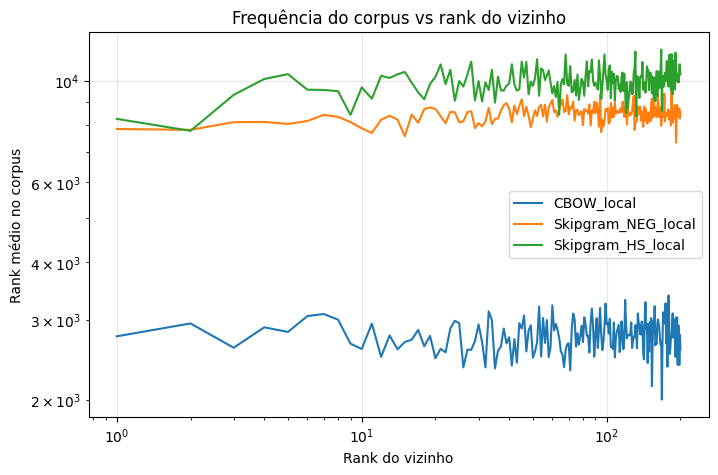

In [26]:

import matplotlib.pyplot as plt

def average_neighbor_frequency_curve(kv, queries, rank_map, topn=200):
    sums = defaultdict(list)
    usable_queries = [q for q in queries if q in kv]
    for q in tqdm(usable_queries, desc="curva freq-vizinhos"):
        neigh = kv.most_similar(q, topn=topn)
        for idx, (cand, _) in enumerate(neigh, start=1):
            if cand in rank_map:
                sums[idx].append(rank_map[cand])

    rows = []
    for idx in sorted(sums):
        rows.append({
            "neighbor_rank": idx,
            "avg_corpus_rank": float(np.mean(sums[idx])),
        })
    return pd.DataFrame(rows)

freq_curve_queries = effective_queries[:100]
freq_curves = {}

for model_name, kv in models.items():
    if freq_curve_queries:
        freq_curves[model_name] = average_neighbor_frequency_curve(kv, freq_curve_queries, reference_rank, topn=200)

plt.figure(figsize=(8, 5))
for model_name, curve in freq_curves.items():
    plt.plot(curve["neighbor_rank"], curve["avg_corpus_rank"], label=model_name)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Rank do vizinho")
plt.ylabel("Rank médio no corpus")
plt.title("Frequência do corpus vs rank do vizinho")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 15. Avaliação extrínseca: sentiment classification


In [27]:

from datasets import load_dataset

imdb = load_dataset("imdb")

train_texts = imdb["train"]["text"]
train_labels = np.array(imdb["train"]["label"])
test_texts = imdb["test"]["text"]
test_labels = np.array(imdb["test"]["label"])

if IMDB_SAMPLE_PER_SPLIT is not None:
    train_texts = train_texts[:IMDB_SAMPLE_PER_SPLIT]
    train_labels = train_labels[:IMDB_SAMPLE_PER_SPLIT]
    test_texts = test_texts[:IMDB_SAMPLE_PER_SPLIT]
    test_labels = test_labels[:IMDB_SAMPLE_PER_SPLIT]

len(train_texts), len(test_texts)


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

(3000, 3000)

In [28]:

def document_embedding(text, kv):
    tokens = simple_tokenize(text)
    if not tokens:
        return np.zeros(kv.vector_size, dtype=np.float32)

    counts = Counter(tokens)
    vec = np.zeros(kv.vector_size, dtype=np.float32)
    total = 0

    for w, c in counts.items():
        if w in kv:
            vec += kv[w] * c
            total += c

    if total > 0:
        vec = vec / total

    norm = np.linalg.norm(vec)
    if norm > 0:
        vec = vec / norm
    return vec.astype(np.float32)

def build_doc_matrix(texts, kv):
    return np.vstack([document_embedding(t, kv) for t in tqdm(texts, desc="doc embeddings")])


In [30]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

sent_rows = []

unique_train = np.unique(train_labels)

if len(unique_train) < 2:
    print("Seção de sentiment pulada.")
    print(f"train_labels contém apenas uma classe: {unique_train}")
    sentiment_df = pd.DataFrame()
else:
    # baseline BoW
    bow = CountVectorizer(max_features=20000, stop_words="english")
    X_train_bow = bow.fit_transform(train_texts)
    X_test_bow = bow.transform(test_texts)

    clf_bow = LogisticRegression(max_iter=1000, random_state=SEED)
    clf_bow.fit(X_train_bow, train_labels)
    pred_bow = clf_bow.predict(X_test_bow)

    sent_rows.append({
        "model": "baseline_bow",
        "accuracy": accuracy_score(test_labels, pred_bow),
        "f1": f1_score(test_labels, pred_bow),
    })

    for model_name, kv in models.items():
        X_train = build_doc_matrix(train_texts, kv)
        X_test = build_doc_matrix(test_texts, kv)

        clf = LogisticRegression(max_iter=1000, random_state=SEED)
        clf.fit(X_train, train_labels)
        preds = clf.predict(X_test)

        sent_rows.append({
            "model": model_name,
            "accuracy": accuracy_score(test_labels, preds),
            "f1": f1_score(test_labels, preds),
        })

    sentiment_df = pd.DataFrame(sent_rows).sort_values("f1", ascending=False)
    sentiment_df.to_csv(OUTPUT_DIR / "sentiment_results.csv", index=False)
    display(sentiment_df)

Seção de sentiment pulada.
train_labels contém apenas uma classe: [0]


## 16. Avaliação extrínseca: noun phrase chunking com CRF


In [31]:

from nltk.corpus import conll2000

def tree_to_iob_sentences(fileid):
    out = []
    for tree in conll2000.chunked_sents(fileid, chunk_types=["NP"]):
        sent = nltk.chunk.tree2conlltags(tree)
        out.append([(w, p, c) for w, p, c in sent])
    return out

chunk_train = tree_to_iob_sentences("train.txt")
chunk_test = tree_to_iob_sentences("test.txt")

if CHUNK_TRAIN_LIMIT is not None:
    chunk_train = chunk_train[:CHUNK_TRAIN_LIMIT]
if CHUNK_TEST_LIMIT is not None:
    chunk_test = chunk_test[:CHUNK_TEST_LIMIT]

len(chunk_train), len(chunk_test), chunk_train[0][:10]


(2000,
 500,
 [('Confidence', 'NN', 'B-NP'),
  ('in', 'IN', 'O'),
  ('the', 'DT', 'B-NP'),
  ('pound', 'NN', 'I-NP'),
  ('is', 'VBZ', 'O'),
  ('widely', 'RB', 'O'),
  ('expected', 'VBN', 'O'),
  ('to', 'TO', 'O'),
  ('take', 'VB', 'O'),
  ('another', 'DT', 'B-NP')])

In [32]:

def token2features(sent, i, kv=None, emb_dim=None):
    word, pos, _ = sent[i]
    word_l = word.lower()

    feats = {
        "bias": 1.0,
        "word.lower": word_l,
        "word[-3:]": word_l[-3:],
        "word[-2:]": word_l[-2:],
        "word.isupper": word.isupper(),
        "word.istitle": word.istitle(),
        "word.isdigit": word.isdigit(),
        "pos": pos,
        "pos[:2]": pos[:2],
    }

    if i > 0:
        pw, ppos, _ = sent[i - 1]
        feats.update({
            "-1:word.lower": pw.lower(),
            "-1:pos": ppos,
        })
    else:
        feats["BOS"] = True

    if i < len(sent) - 1:
        nw, npos, _ = sent[i + 1]
        feats.update({
            "+1:word.lower": nw.lower(),
            "+1:pos": npos,
        })
    else:
        feats["EOS"] = True

    if kv is not None:
        vec = safe_vector(kv, word_l, dim=emb_dim)
        for j, val in enumerate(vec):
            feats[f"emb_{j}"] = float(val)

    return feats

def sent2features(sent, kv=None, emb_dim=None):
    return [token2features(sent, i, kv=kv, emb_dim=emb_dim) for i in range(len(sent))]

def sent2labels(sent):
    return [label for _, _, label in sent]

def flatten_labels(y):
    return [lab for sent in y for lab in sent]

X_train_base = [sent2features(s, kv=None) for s in tqdm(chunk_train, desc="chunk baseline train feats")]
X_test_base = [sent2features(s, kv=None) for s in tqdm(chunk_test, desc="chunk baseline test feats")]
y_train_chunk = [sent2labels(s) for s in chunk_train]
y_test_chunk = [sent2labels(s) for s in chunk_test]


chunk baseline train feats:   0%|          | 0/2000 [00:00<?, ?it/s]

chunk baseline test feats:   0%|          | 0/500 [00:00<?, ?it/s]

In [33]:

chunk_rows = []

# baseline CRF
crf_base = sklearn_crfsuite.CRF(
    algorithm="lbfgs",
    c1=0.1,
    c2=0.1,
    max_iterations=50 if FAST_MODE else 100,
    all_possible_transitions=False,
)
crf_base.fit(X_train_base, y_train_chunk)
pred_base = crf_base.predict(X_test_base)

chunk_rows.append({
    "model": "baseline_crf",
    "f1": seq_f1_score(y_test_chunk, pred_base),
})

for model_name, kv in models.items():
    X_train = [sent2features(s, kv=kv, emb_dim=EMBEDDING_DIM_FOR_CHUNK) for s in tqdm(chunk_train, desc=f"{model_name} train feats")]
    X_test = [sent2features(s, kv=kv, emb_dim=EMBEDDING_DIM_FOR_CHUNK) for s in tqdm(chunk_test, desc=f"{model_name} test feats")]

    crf = sklearn_crfsuite.CRF(
        algorithm="lbfgs",
        c1=0.1,
        c2=0.1,
        max_iterations=50 if FAST_MODE else 100,
        all_possible_transitions=False,
    )
    crf.fit(X_train, y_train_chunk)
    preds = crf.predict(X_test)

    chunk_rows.append({
        "model": model_name,
        "f1": seq_f1_score(y_test_chunk, preds),
    })

chunk_df = pd.DataFrame(chunk_rows).sort_values("f1", ascending=False)
chunk_df.to_csv(OUTPUT_DIR / "chunking_results.csv", index=False)
display(chunk_df)


CBOW_local train feats:   0%|          | 0/2000 [00:00<?, ?it/s]

CBOW_local test feats:   0%|          | 0/500 [00:00<?, ?it/s]

Skipgram_NEG_local train feats:   0%|          | 0/2000 [00:00<?, ?it/s]

Skipgram_NEG_local test feats:   0%|          | 0/500 [00:00<?, ?it/s]

Skipgram_HS_local train feats:   0%|          | 0/2000 [00:00<?, ?it/s]

Skipgram_HS_local test feats:   0%|          | 0/500 [00:00<?, ?it/s]

,model,f1
2,Skipgram_NEG_local,0.921857
3,Skipgram_HS_local,0.920892
1,CBOW_local,0.920231
0,baseline_crf,0.920053


## 17. Resumo consolidado


In [35]:
summary = pd.DataFrame({"model": list(models.keys())})

# --------------------------------------------------
# Similarity (somente se existir)
# --------------------------------------------------
if "sim_results_df" in globals() and not sim_results_df.empty and {"model", "spearman_rho"}.issubset(sim_results_df.columns):
    sim_avg = (
        sim_results_df.groupby("model", as_index=False)["spearman_rho"]
        .mean()
        .rename(columns={"spearman_rho": "avg_similarity_rho"})
    )
    summary = summary.merge(sim_avg, on="model", how="left")
else:
    summary["avg_similarity_rho"] = np.nan

# --------------------------------------------------
# Analogies
# --------------------------------------------------
if "analogy_overall_df" in globals() and not analogy_overall_df.empty and {"model", "overall_accuracy"}.issubset(analogy_overall_df.columns):
    summary = summary.merge(
        analogy_overall_df[["model", "overall_accuracy"]],
        on="model",
        how="left",
    )
else:
    summary["overall_accuracy"] = np.nan

# --------------------------------------------------
# Coherence proxy
# --------------------------------------------------
if "proxy_df" in globals() and not proxy_df.empty and {"model", "proxy_margin"}.issubset(proxy_df.columns):
    coh = (
        proxy_df.groupby("model", as_index=False)["proxy_margin"]
        .mean()
        .rename(columns={"proxy_margin": "avg_coherence_proxy"})
    )
    summary = summary.merge(coh, on="model", how="left")
else:
    summary["avg_coherence_proxy"] = np.nan

# --------------------------------------------------
# Frequency probe
# --------------------------------------------------
if "probe_df" in globals() and not probe_df.empty and {"model", "cv_accuracy_mean"}.issubset(probe_df.columns):
    freq_avg = (
        probe_df.groupby("model", as_index=False)["cv_accuracy_mean"]
        .mean()
        .rename(columns={"cv_accuracy_mean": "avg_frequency_probe_acc"})
    )
    summary = summary.merge(freq_avg, on="model", how="left")
else:
    summary["avg_frequency_probe_acc"] = np.nan

# --------------------------------------------------
# Sentiment (somente se existir)
# --------------------------------------------------
if "sentiment_df" in globals() and not sentiment_df.empty and {"model", "f1"}.issubset(sentiment_df.columns):
    sent_tmp = sentiment_df.copy()
    if "baseline_bow" in sent_tmp["model"].values:
        sent_tmp = sent_tmp[sent_tmp["model"] != "baseline_bow"]

    summary = summary.merge(
        sent_tmp[["model", "f1"]].rename(columns={"f1": "sentiment_f1"}),
        on="model",
        how="left",
    )
else:
    summary["sentiment_f1"] = np.nan

# --------------------------------------------------
# Chunking (somente se existir)
# --------------------------------------------------
if "chunk_df" in globals() and not chunk_df.empty and {"model", "f1"}.issubset(chunk_df.columns):
    chunk_tmp = chunk_df.copy()
    if "baseline_crf" in chunk_tmp["model"].values:
        chunk_tmp = chunk_tmp[chunk_tmp["model"] != "baseline_crf"]

    summary = summary.merge(
        chunk_tmp[["model", "f1"]].rename(columns={"f1": "chunking_f1"}),
        on="model",
        how="left",
    )
else:
    summary["chunking_f1"] = np.nan

summary.to_csv(OUTPUT_DIR / "summary.csv", index=False)
display(summary.sort_values(["avg_coherence_proxy", "overall_accuracy"], ascending=False))

,model,avg_similarity_rho,overall_accuracy,avg_coherence_proxy,avg_frequency_probe_acc,sentiment_f1,chunking_f1
2,Skipgram_HS_local,NaN,0.040546,0.117876,0.65264,NaN,0.920892
1,Skipgram_NEG_local,NaN,0.010415,0.000909,0.68740,NaN,0.921857
0,CBOW_local,NaN,0.000248,0.000021,0.87924,NaN,0.920231


## 18. Arquivos exportados


In [36]:

print("Arquivos gerados em:", OUTPUT_DIR.resolve())
for p in sorted(OUTPUT_DIR.glob("*")):
    print("-", p.name)


Arquivos gerados em: /content/cornell_embedding_eval/outputs
- analogy_overall.csv
- chunking_results.csv
- coherence_proxy_results.csv
- cornell_direct_comparison_tasks.csv
- cornell_intrusion_tasks.csv
- cornell_judgements_overview.csv
- cornell_query_inventory_normalized.csv
- frequency_probe_results.csv
- query_inventory_effective.csv
- similarity_results.csv
- summary.csv


## 19. Interpretação esperada

Este notebook foi desenhado para ser útil em dois regimes:

### Regime A: rápido
- `FAST_MODE=True`
- treino local em `text8`
- uso do `query_inventory` e dos `judgements` do Cornell
- bom para inspeção didática e prototipagem

### Regime B: mais fiel ao paper
- `DOWNLOAD_RELEASED_WIKI=True`
- `USE_RELEASED_WIKI_FOR_TRAINING=True`
- `DOWNLOAD_RELEASED_EMBEDDINGS=True`
- preencher `SELECT_RELEASED_PATTERNS` com os nomes desejados
- mais demorado, mas mais próximo do protocolo histórico do artigo

Dicas:
- para **reprodução prática**, use os CSVs exportados em `outputs/`
- para **comparação humana**, anote os arquivos `cornell_direct_comparison_tasks.csv` e `cornell_intrusion_tasks.csv`
- para **comparação com o material liberado**, inspecione `cornell_judgements_overview.csv`
